In [19]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np 

In [20]:
df = pd.read_csv("D:\\AIML_SEM6\\LinearRegression\\crop-yield.csv")

In [21]:
df.head(5)

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [22]:
X = df[['N','P','K','Soil_pH','Soil_Moisture','Organic_Carbon','Temperature','Humidity','Rainfall','Sunlight_Hours','Wind_Speed','Altitude','Fertilizer_Used','Pesticide_Used']]
y = df['Crop_Yield_ton_per_hectare']

In [23]:
X.head(5)

,N,P,K,Soil_pH,Soil_Moisture,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Altitude,Fertilizer_Used,Pesticide_Used
0,132,62,22,6.35,59.78,0.43,22.97,53.89,1305.68,7.73,15.96,36,223.48,23.36
1,122,71,66,5.98,25.54,0.65,17.00,76.90,1942.05,9.25,12.60,1561,161.54,4.42
2,44,35,104,8.07,25.87,0.79,25.52,44.78,2216.20,8.50,15.63,1870,184.62,6.29
3,136,96,113,4.83,42.97,0.45,18.59,31.89,607.18,8.75,5.49,765,274.02,2.72
4,101,34,42,5.84,48.01,0.69,22.74,46.27,483.47,8.00,7.44,1143,72.69,15.37


In [24]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 2 ,test_size=0.2)

In [25]:
lr = LinearRegression()
model = lr.fit(X_train,y_train.values.reshape(-1,1))
y_pred = lr.predict(X_test)



In [26]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


--- Model Performance ---
Mean Absolute Error (MAE): 17.371727312490535
Mean Squared Error (MSE): 533.9261595855186
Root Mean Squared Error (RMSE): 23.10684226772491
R2 Score: -0.001965363257750097


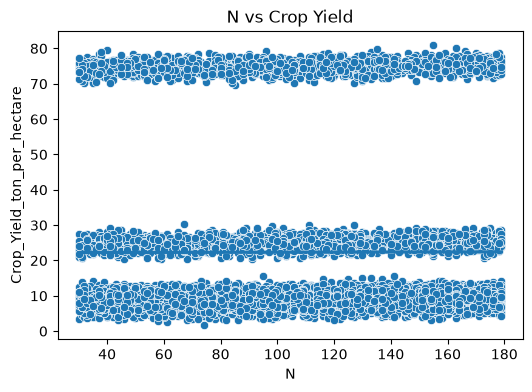

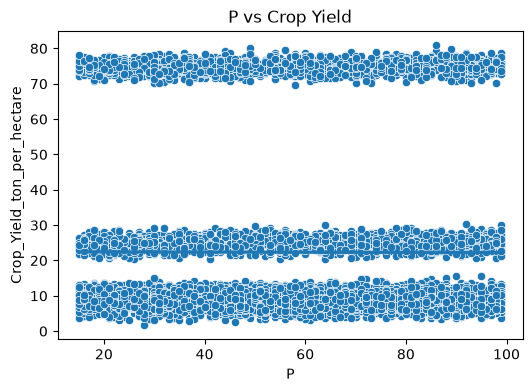

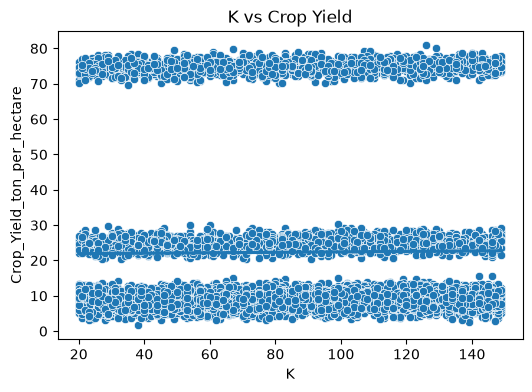

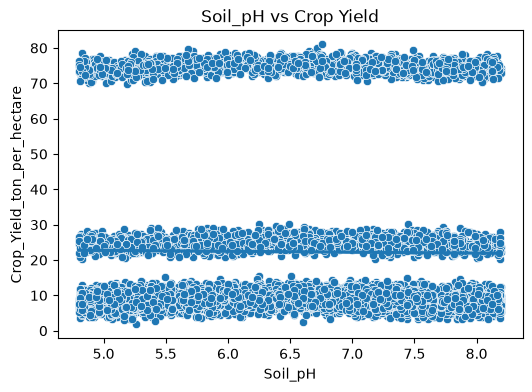

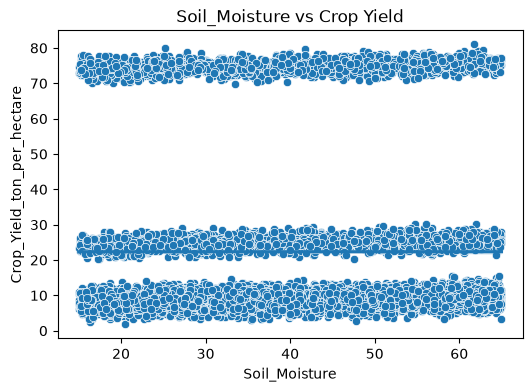

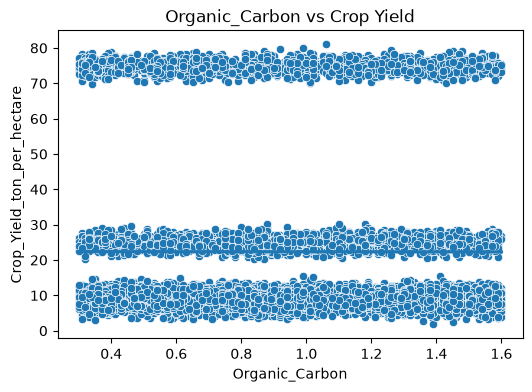

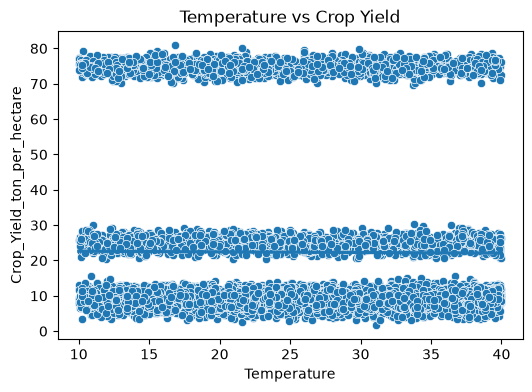

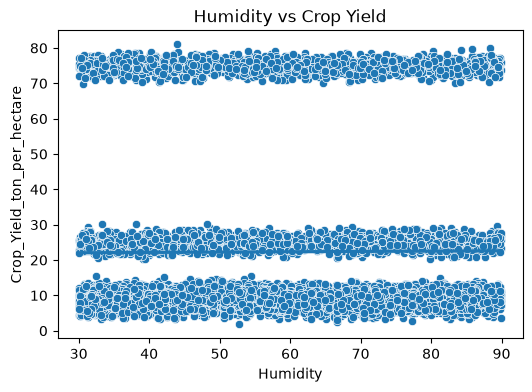

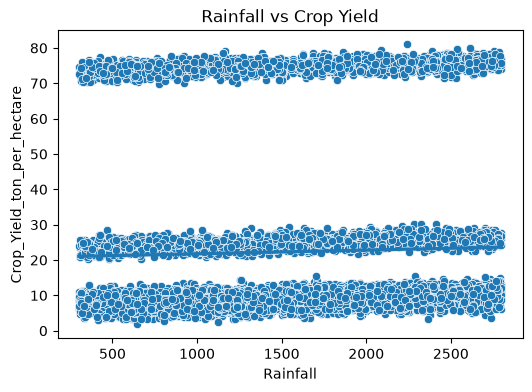

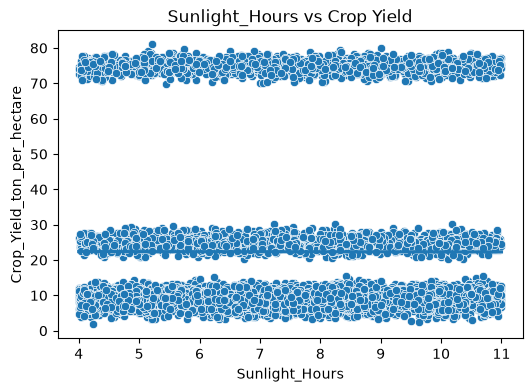

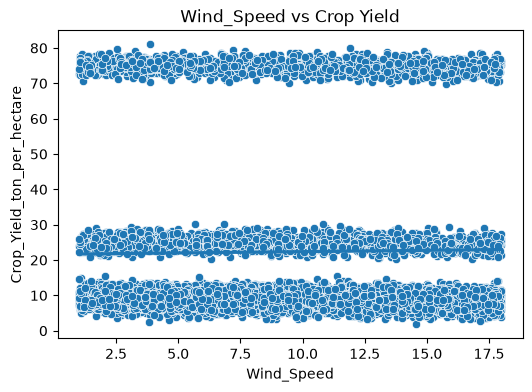

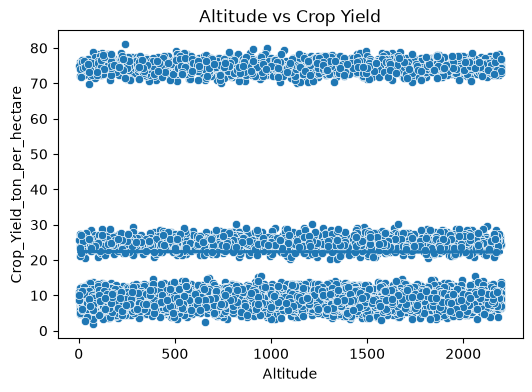

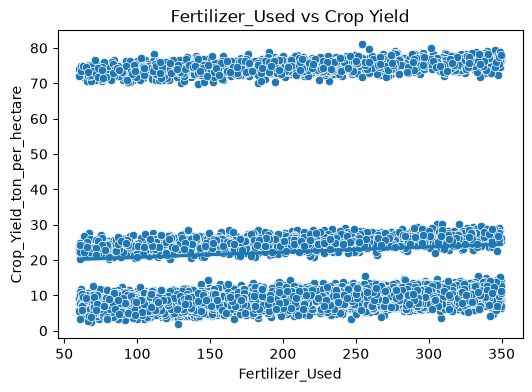

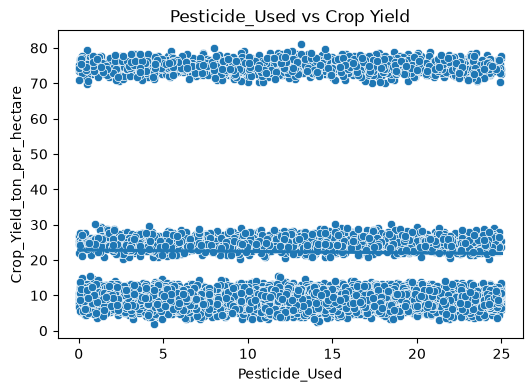

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'N', 'P', 'K', 'Soil_pH', 'Soil_Moisture',
    'Organic_Carbon', 'Temperature', 'Humidity',
    'Rainfall', 'Sunlight_Hours', 'Wind_Speed',
    'Altitude', 'Fertilizer_Used', 'Pesticide_Used'
]

for feature in features:
    plt.figure(figsize=(6, 4))

    sns.scatterplot(
        data=df,
        x=feature,
        y='Crop_Yield_ton_per_hectare'
    )

    sns.regplot(
        data=df,
        x=feature,
        y='Crop_Yield_ton_per_hectare',
        scatter=False
    )

    plt.title(f'{feature} vs Crop Yield')
    plt.show()

**The distinct horizontal banding across all plots indicates that individual numerical features lack a direct linear relationship with crop yield, suggesting that the variations are instead driven by underlying categorical factors like crop or soil type.**

In [28]:
# Correlation with target
print(
    df.select_dtypes(include='number')
      .corr()['Crop_Yield_ton_per_hectare']
      .sort_values()
)

Pesticide_Used               -0.012060
Soil_pH                      -0.010509
Temperature                  -0.006589
P                            -0.002483
Altitude                     -0.001562
Sunlight_Hours               -0.001162
Organic_Carbon               -0.000781
Soil_Moisture                 0.000152
N                             0.002334
Humidity                      0.006916
K                             0.009897
Wind_Speed                    0.015185
Rainfall                      0.031213
Fertilizer_Used               0.051371
Crop_Yield_ton_per_hectare    1.000000
Name: Crop_Yield_ton_per_hectare, dtype: float64
